## Load and Setup

In [1]:
import duckdb 
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
conn = duckdb.connect()
PARQUET_PATH = Path("../data/processed/master_events.parquet").as_posix()


In [2]:
query = f"""
        SELECT * 
        FROM '{PARQUET_PATH}'
        LIMIT 5
"""

conn.execute(query).df()
 

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00,remove_from_cart,5712790,1487580005268456287,None,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00,view,5764655,1487580005411062629,None,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02,cart,4958,1487580009471148064,None,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05,view,5848413,1487580007675986893,None,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07,view,5824148,1487580005511725929,None,None,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5


## Data Quality Check


In [3]:
query = f"""
        SELECT COUNT(*) 
        FROM '{PARQUET_PATH}'
        WHERE price <= 0
        """
conn.execute(query).df()


,count_star()
0,104288


In [4]:
query = f"""

    SELECT AVG(price), event_type, user_session
    FROM '{PARQUET_PATH}'
    WHERE price < 0 
    GROUP BY user_session, event_type
    
"""

conn.execute(query).df()

,avg(price),event_type,user_session
0,-15.87,purchase,8a241707-6478-4b00-9359-01e146f7cb7d
1,-47.62,purchase,140d150d-abd0-4202-b6a5-ce0525b2ced4
2,-23.81,purchase,c28441e1-869c-44d9-adf0-c21f6aea6f70
3,-23.81,purchase,f5e7e124-1d3b-240c-a2c0-c11874b9ff78
4,-15.87,purchase,9b8a472e-a661-6a6f-deb9-6919ffe9f247
...,...,...,...
111,-7.94,purchase,34fa4291-9e2e-470f-a678-b84d9bbbdfe3
112,-23.81,purchase,293e58c2-8587-4ad6-bc94-5acb00eefb02
113,-47.62,purchase,f6ad01f2-340f-42f1-95ee-528364889a69
114,-47.62,purchase,53330931-d72e-4e5c-9333-69108fa0f35a


In [5]:
query = f"""

    SELECT price
    FROM '{PARQUET_PATH}'
    WHERE price < 0 
    GROUP BY price
"""

neg_values = conn.execute(query).df()
neg_values.head(30)

,price
0,-23.81
1,-79.37
2,-7.94
3,-15.87
4,-47.62


In [6]:
query = f"""

    SELECT event_type, COUNT(*) as count
    FROM '{PARQUET_PATH}'
    WHERE price = 0
    GROUP BY event_type, 
    
    
"""

conn.execute(query).df()

,event_type,count
0,view,30490
1,cart,49370
2,purchase,1
3,remove_from_cart,24296


In [7]:
query = f"""

    SELECT *
    FROM '{PARQUET_PATH}'
    WHERE price = 0 AND event_type = 'purchase'
    
"""

anomaly_purchase = conn.execute(query).df()

red_flag_sessions = []
red_flag_sessions = anomaly_purchase['user_session'].tolist()


In [8]:
query = f"""

    SELECT event_type, COUNT(*) as count
    FROM '{PARQUET_PATH}'
    WHERE price < 0
    GROUP BY event_type, 
    
    
"""

conn.execute(query).df()

,event_type,count
0,view,2
1,remove_from_cart,3
2,purchase,126


In [9]:
query = f"""

    SELECT *
    FROM '{PARQUET_PATH}'
    WHERE price < 0 AND event_type = 'view'
    
"""
conn.execute(query).df()



,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-01-05 10:49:53,view,5716857,1487580014042939619,None,None,-23.81,439078759,4a07f317-1335-4706-ac80-5a25a9c22581
1,2020-01-27 08:04:32,view,5716861,1487580014042939619,None,None,-79.37,531900924,38fe5484-6b5f-44e6-8092-3713df449df7


In [10]:
query = f"""
    SELECT 
        SUM(CASE WHEN event_time is NULL THEN 1 ELSE 0 END) as missing_event_times,
        SUM(CASE WHEN event_type is NULL THEN 1 ELSE 0 END) as missing_event_types,
        SUM(CASE WHEN product_id is NULL THEN 1 ELSE 0 END) as missing_product_ids,
        SUM(CASE WHEN category_id is NULL THEN 1 ELSE 0 END) as missing_category_ids,
        SUM(CASE WHEN category_code is NULL THEN 1 ELSE 0 END) as missing_category_codes,
        SUM(CASE WHEN brand is NULL THEN 1 ELSE 0 END) as missing_brands,
        SUM(CASE WHEN price is NULL THEN 1 ELSE 0 END) as missing_prices,
        SUM(CASE WHEN user_id is NULL THEN 1 ELSE 0 END) as missing_user_ids,
        SUM(CASE WHEN user_session is NULL THEN 1 ELSE 0 END) as missing_user_session,
    FROM '{PARQUET_PATH}'
    WHERE price >= 0
"""

conn.execute(query).df()

,missing_event_times,missing_event_types,missing_product_ids,missing_category_ids,missing_category_codes,missing_brands,missing_prices,missing_user_ids,missing_user_session
0,0.0,0.0,0.0,0.0,20339115.0,8756986.0,0.0,0.0,4598.0


# Negative / Zero Price Items

The majority of negative items are purchases, suggesting that they are refunds. One anomaly row was flagged into `red_flag_session` to be removed in later processing

## Event Type Distributions


,event_type,event_count
0,view,9657821
1,cart,5768333
2,remove_from_cart,3979679
3,purchase,1287007


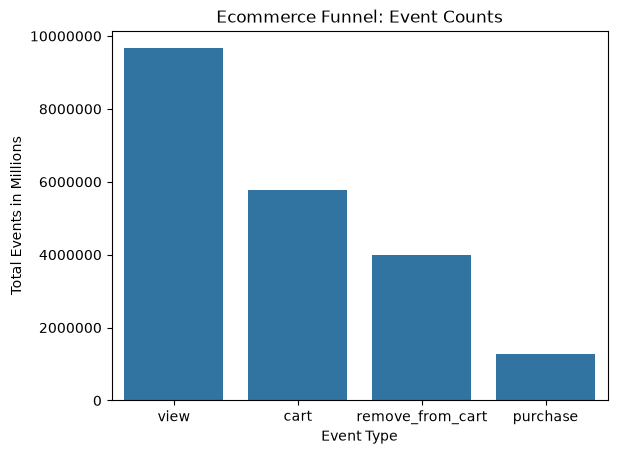

In [11]:
query = f"""

    SELECT event_type, COUNT(*) as event_count
    FROM '{PARQUET_PATH}'
    GROUP BY event_type 
    ORDER BY event_count DESC
    
    
"""

event_occurrence = conn.execute(query).df()
display(event_occurrence)

sns.barplot(
    data = event_occurrence,
    x = 'event_type',
    y = 'event_count'
)

plt.title("Ecommerce Funnel: Event Counts")
plt.xlabel("Event Type")
plt.ylabel("Total Events in Millions")
plt.ticklabel_format(style='plain', axis='y') 
plt.show()

In [12]:
view_to_cart = round(event_occurrence["event_count"][1] / event_occurrence["event_count"][0], 3)
remove_rate = round(event_occurrence["event_count"][2] / event_occurrence["event_count"][1], 3)
cart_to_purchase = round(event_occurrence["event_count"][3] / event_occurrence["event_count"][1], 3)
view_to_purchase = round(event_occurrence["event_count"][3] / event_occurrence["event_count"][0], 3)

data = {
    "Conversion Metric" : ["View To Cart", "Cart to Remove Ratio", "Cart to Purchase", "View to Purchase"],
    "Rate" : [view_to_cart, remove_rate, cart_to_purchase, view_to_purchase] 
}

event_rates = pd.DataFrame(data)
display(event_rates)

,Conversion Metric,Rate
0,View To Cart,0.597
1,Cart to Remove Ratio,0.690
2,Cart to Purchase,0.223
3,View to Purchase,0.133


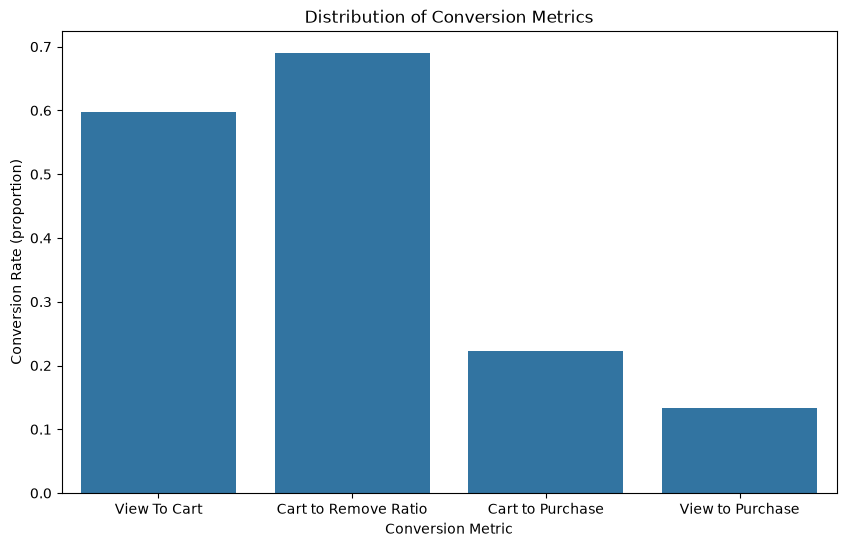

In [13]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data = event_rates,
    x = "Conversion Metric",
    y = "Rate"
)

plt.title("Distribution of Conversion Metrics")
plt.ylabel("Conversion Rate (proportion)")
plt.show()

<Axes: xlabel='purchase_date', ylabel='daily_purchases'>

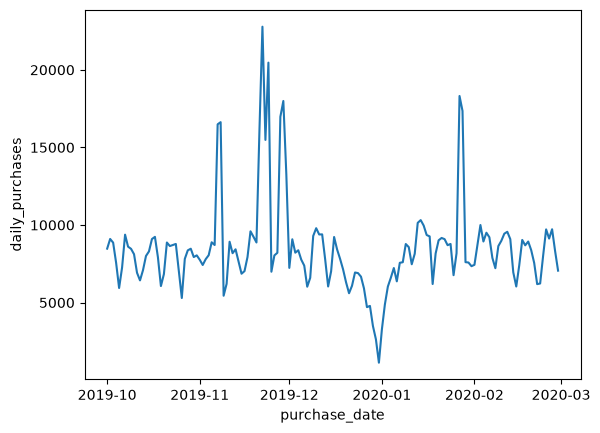

In [14]:
query = f"""

    SELECT 
        DATE_TRUNC('day', CAST(event_time AS TIMESTAMP)) AS purchase_date,
        COUNT(*) as daily_purchases
    FROM '{PARQUET_PATH}'
    WHERE event_type = 'purchase'
    GROUP BY purchase_date
    ORDER BY purchase_date
    
"""
df_trend = conn.execute(query).df()

sns.lineplot(
    data = df_trend,
    x= 'purchase_date',
    y = 'daily_purchases'
)

Text(0, 0.5, 'Monthly ACtive Users')

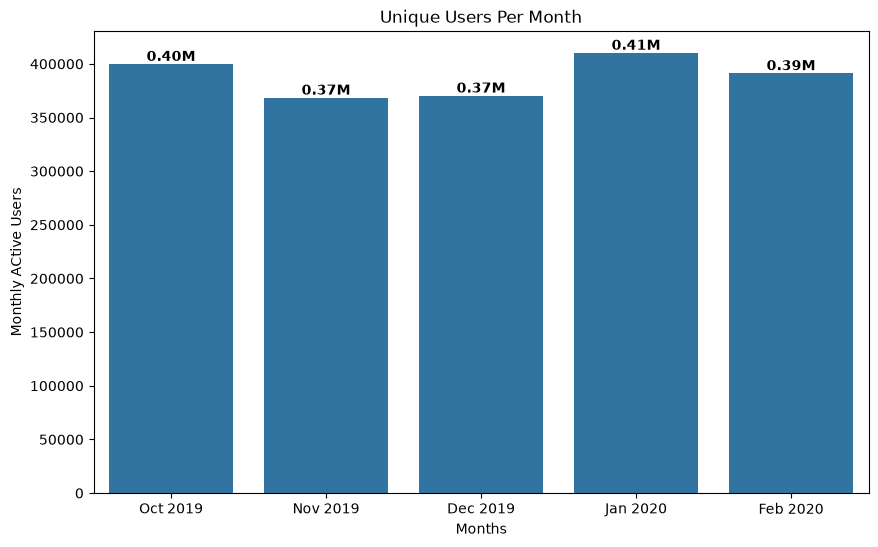

In [15]:
query = f"""

    SELECT 
        DATE_TRUNC('month', CAST(event_time AS TIMESTAMP)) AS month,
        COUNT(DISTINCT user_id) AS unique_users
    FROM '{PARQUET_PATH}'
    GROUP BY month
    ORDER BY month ASC
    
"""


unique_users_per_month = conn.execute(query).df()
unique_users_per_month['month'] = pd.to_datetime(unique_users_per_month['month']).dt.strftime('%b %Y')

plt.figure(figsize = (10,6))
ax = sns.barplot(
    data = unique_users_per_month,
    x= 'month',
    y = 'unique_users'
)

ax.bar_label(
    ax.containers[0], 
    fmt=lambda x: f"{x*1e-6:.2f}M",  
    fontweight='bold'
)

plt.title("Unique Users Per Month")
plt.xlabel("Months")
plt.ylabel("Monthly ACtive Users")

<Axes: xlabel='unique_purchases', ylabel='Count'>

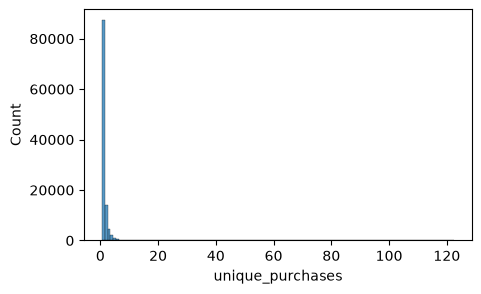

In [16]:
query = f"""
   
    SELECT 
        COUNT(DISTINCT user_session) AS unique_purchases
    FROM '{PARQUET_PATH}'
    WHERE event_type = 'purchase' 
    GROUP BY user_id
    ORDER BY unique_purchases ASC
    
"""
unique_purchases = conn.execute(query).df()

plt.figure(figsize = (5,3))
sns.histplot(
    data=unique_purchases,
    x = "unique_purchases",
    discrete=True,
    kde = False
             )

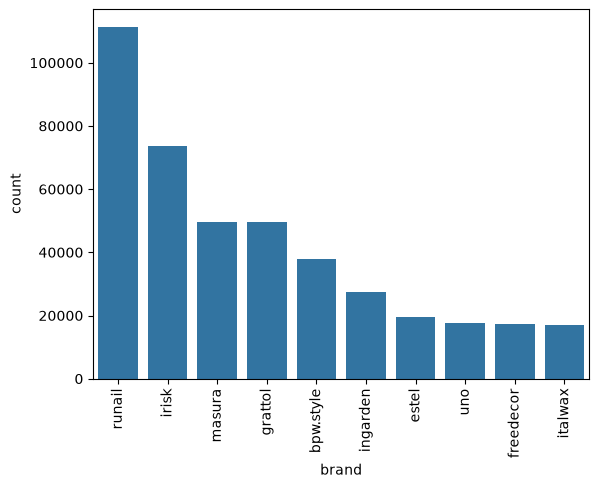

In [17]:
query = f"""
   
    SELECT brand, COUNT() as count
    FROM '{PARQUET_PATH}'
    WHERE event_type = 'purchase' AND brand IS NOT NULL
    GROUP BY brand
    ORDER BY count DESC
    LIMIT 10
"""

most_bought_brands = conn.execute(query).df()
ax = sns.barplot(
    data=most_bought_brands,
    x = 'brand',
    y = 'count'
)
plt.xticks(rotation = 'vertical')

plt.show()

In [18]:
query = f"""
   
    SELECT user_id, COUNT(DISTINCT user_session) AS purchase_count 
    FROM '{PARQUET_PATH}'
    WHERE event_type = 'purchase'
    GROUP BY user_id

"""
purchase_count = conn.execute(query).df()
single = round((purchase_count["purchase_count"] == 1).sum() / len(purchase_count),3)
repeat = round((purchase_count["purchase_count"] > 1).sum() / len(purchase_count),3)

single_vs_repeat = pd.DataFrame({
    'Metric': ['Single Purchases', 'Repeat Purchases'],
    'Count' : [(purchase_count["purchase_count"] == 1).sum(), (purchase_count["purchase_count"] > 1).sum()],
    'Ratio': [single, repeat]
        
    })

single_vs_repeat

,Metric,Count,Ratio
0,Single Purchases,87215,0.789
1,Repeat Purchases,23303,0.211


In [19]:
query = f"""
    SELECT
        event_time,
        product_id,
        category_id,
        category_code,
        brand,
        price,
        CASE WHEN price < 0 THEN 1 ELSE 0 END AS is_refund,
        user_id,
        user_session
    FROM '{PARQUET_PATH}'
    WHERE event_type = 'purchase'
"""

purchases = conn.execute(query).df().sort_values("event_time")
purchases = purchases[~purchases['user_session'].isin(red_flag_sessions)]

print(f"Total purchases: {len(purchases)}")
print(f"Refund rows: {purchases['is_refund'].sum()}")


output_path = Path("../data/processed/purchases.parquet")
output_path.parent.mkdir(parents=True, exist_ok=True)
purchases.to_parquet(output_path, index=False)

Total purchases: 1286994
Refund rows: 126
